---
categories
- PPEC
- Ensino
- Estatística
date: 2026-07-09
description: Nona Aula
image: analise.jpg
title: "Aula 9 - Análise de Experimentos" 

# Análise Comparativa da Durabilidade de Concretos Convencional, CAD e UHPC

## Carbonatação e Penetração de Cloretos

### Autora
Elisama Oliveira Freitas

### Objetivo

Comparar o comportamento de concretos convencional (CC), de alto desempenho (CAD) e de ultra alto desempenho (UHPC) em relação aos principais mecanismos de degradação associados à durabilidade das estruturas de concreto armado.

Os mecanismos analisados são:

- Carbonatação
- Penetração de cloretos

Além disso, serão aplicadas técnicas estatísticas e de aprendizado de máquina para interpretação dos resultados.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_style('whitegrid')

# Base de Dados

Os dados utilizados representam resultados experimentais típicos encontrados na literatura para concretos convencional, CAD e UHPC.

A variável profundidade de carbonatação é expressa em milímetros (mm).

O coeficiente de difusão de cloretos é representado em unidades relativas para comparação dos materiais.

In [6]:
dados = {

'Concreto':['CC']*5 + ['CAD']*5 + ['UHPC']*5,

'Carbonatacao':[8.5,7.8,8.9,9.1,8.2,
                3.0,2.8,3.2,3.1,2.9,
                0.5,0.6,0.7,0.4,0.5],

'Cloretos':[12,11,13,12.5,11.8,
            5,4.5,5.2,4.8,5.1,
            0.8,0.9,0.7,0.8,0.6]
}

df = pd.DataFrame(dados)

df.index = range(1, len(df)+1)

df

,Concreto,Carbonatacao,Cloretos
1,CC,8.5,12.0
2,CC,7.8,11.0
3,CC,8.9,13.0
4,CC,9.1,12.5
5,CC,8.2,11.8
6,CAD,3.0,5.0
7,CAD,2.8,4.5
8,CAD,3.2,5.2
9,CAD,3.1,4.8
10,CAD,2.9,5.1


# Estatística Descritiva

In [7]:
estatisticas = df.groupby('Concreto').agg(
    Media_Carbonatacao=('Carbonatacao','mean'),
    DP_Carbonatacao=('Carbonatacao','std'),
    Media_Cloretos=('Cloretos','mean'),
    DP_Cloretos=('Cloretos','std')
)

estatisticas

,Media_Carbonatacao,DP_Carbonatacao,Media_Cloretos,DP_Cloretos
Concreto,,,,
CAD,3.00,0.158114,4.92,0.277489
CC,8.50,0.524404,12.06,0.753658
UHPC,0.54,0.114018,0.76,0.114018


# Comparação da Carbonatação

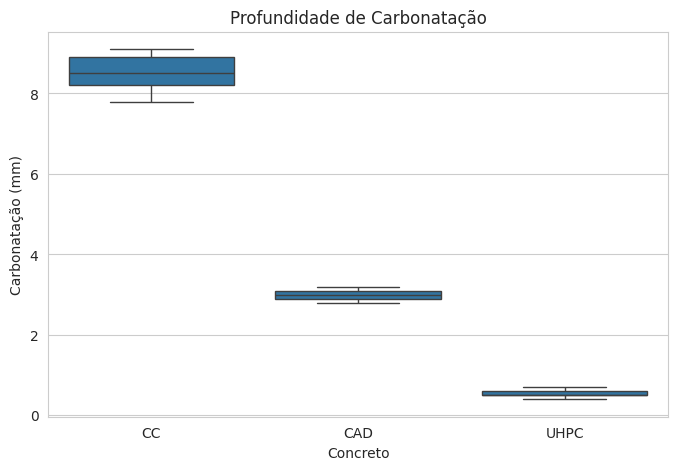

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Concreto',
    y='Carbonatacao'
)

plt.title('Profundidade de Carbonatação')
plt.ylabel('Carbonatação (mm)')
plt.show()

# Comparação da Penetração de Cloretos

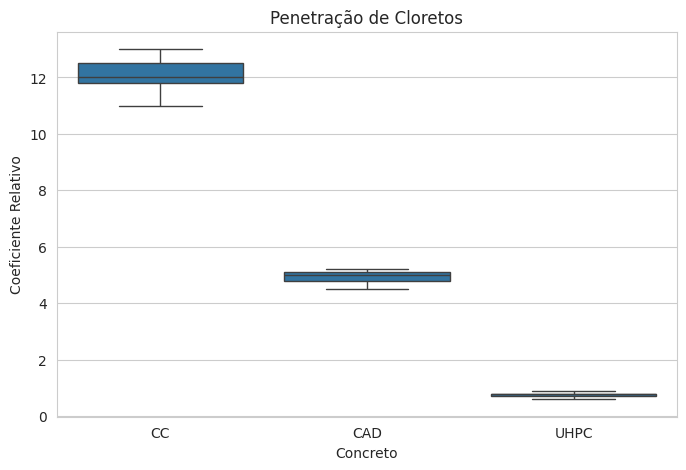

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Concreto',
    y='Cloretos'
)

plt.title('Penetração de Cloretos')
plt.ylabel('Coeficiente Relativo')
plt.show()

# ANOVA para Carbonatação

Hipóteses:

H0 = As médias são iguais.

H1 = Pelo menos uma média é diferente.

In [16]:
cc = df[df['Concreto'] == 'CC']['Carbonatacao']
cad = df[df['Concreto'] == 'CAD']['Carbonatacao']
uhpc = df[df['Concreto'] == 'UHPC']['Carbonatacao']

F, p = f_oneway(cc, cad, uhpc)

print(f'Estatística F = {F:.2f}')
print(f'Valor-p = {p:.4e}')

if p < 0.05:
    print('\nConclusão: Existe diferença significativa entre os concretos.')
else:
    print('\nConclusão: Não existe diferença significativa entre os concretos.')

Estatística F = 796.03
Valor-p = 1.7529e-13

Conclusão: Existe diferença significativa entre os concretos.


# Teste de Tukey para Carbonatação

In [13]:
tukey_carb = pairwise_tukeyhsd(
    df['Carbonatacao'],
    df['Concreto'],
    alpha=0.05
)

print(tukey_carb)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   CAD     CC      5.5   0.0  4.955  6.045   True
   CAD   UHPC    -2.46   0.0 -3.005 -1.915   True
    CC   UHPC    -7.96   0.0 -8.505 -7.415   True
-------------------------------------------------


# ANOVA para Penetração de Cloretos

In [15]:
cc = df[df['Concreto'] == 'CC']['Cloretos']
cad = df[df['Concreto'] == 'CAD']['Cloretos']
uhpc = df[df['Concreto'] == 'UHPC']['Cloretos']

F, p = f_oneway(cc, cad, uhpc)

print(f'Estatística F = {F:.2f}')
print(f'Valor-p = {p:.4e}')

if p < 0.05:
    print('\nConclusão: Existe diferença significativa entre os concretos.')
else:
    print('\nConclusão: Não existe diferença significativa entre os concretos.')

Estatística F = 744.59
Valor-p = 2.6092e-13

Conclusão: Existe diferença significativa entre os concretos.


In [17]:
tukey_cl = pairwise_tukeyhsd(
    df['Cloretos'],
    df['Concreto'],
    alpha=0.05
)

print(tukey_cl)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
   CAD     CC     7.14   0.0   6.3498   7.9302   True
   CAD   UHPC    -4.16   0.0  -4.9502  -3.3698   True
    CC   UHPC    -11.3   0.0 -12.0902 -10.5098   True
-----------------------------------------------------


# Índice de Durabilidade

O índice foi criado para integrar os efeitos da carbonatação e da penetração de cloretos.

Quanto maior o índice, melhor o desempenho do concreto.

In [18]:
df['Indice_Durabilidade'] = 1/(df['Carbonatacao'] + df['Cloretos'])

df

,Concreto,Carbonatacao,Cloretos,Indice_Durabilidade
1,CC,8.5,12.0,0.048780
2,CC,7.8,11.0,0.053191
3,CC,8.9,13.0,0.045662
4,CC,9.1,12.5,0.046296
5,CC,8.2,11.8,0.050000
6,CAD,3.0,5.0,0.125000
7,CAD,2.8,4.5,0.136986
8,CAD,3.2,5.2,0.119048
9,CAD,3.1,4.8,0.126582
10,CAD,2.9,5.1,0.125000


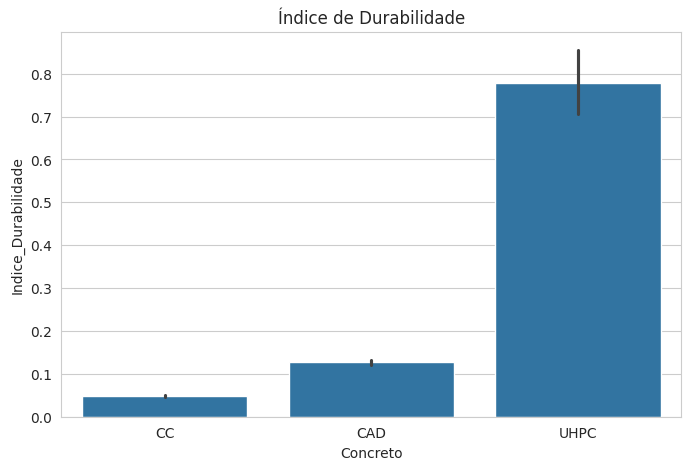

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Concreto',
    y='Indice_Durabilidade'
)

plt.title('Índice de Durabilidade')
plt.show()

# Modelo Preditivo para Carbonatação

Variáveis de entrada:

- Relação água/cimento
- Resistência à compressão
- Porosidade

Variável de saída:

- Carbonatação

In [22]:
np.random.seed(42)

dados_ml = pd.DataFrame({

'ac': np.random.uniform(0.18,0.60,120),

'fck': np.random.uniform(40,180,120),

'porosidade': np.random.uniform(2,18,120)

})

dados_ml['carbonatacao'] = (
    20*dados_ml['ac']
    -0.06*dados_ml['fck']
    +0.6*dados_ml['porosidade']
    +np.random.normal(0,0.5,120)
)

dados_ml.head()
df = pd.DataFrame(dados)

df.index = range(1, len(df)+1)

df

,Concreto,Carbonatacao,Cloretos
1,CC,8.5,12.0
2,CC,7.8,11.0
3,CC,8.9,13.0
4,CC,9.1,12.5
5,CC,8.2,11.8
6,CAD,3.0,5.0
7,CAD,2.8,4.5
8,CAD,3.2,5.2
9,CAD,3.1,4.8
10,CAD,2.9,5.1


In [26]:
X = dados_ml[['ac','fck','porosidade']]
y = dados_ml['carbonatacao']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [25]:
modelo = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo.fit(X_train,y_train)

pred = modelo.predict(X_test)

print('R² =',r2_score(y_test,pred))

R² = 0.8847445328929635


In [32]:
importances = pd.DataFrame({

'Variavel': X.columns,
'Importancia': modelo.feature_importances_

})

importances = importances.sort_values(
    by='Importancia',
    ascending=False
)

importances.index = range(1, len(importances)+1)

importances

,Variavel,Importancia
1,porosidade,0.422483
2,ac,0.301318
3,fck,0.276199


# Estimativa Simplificada da Vida Útil

Utilizando a Lei da Carbonatação:

x = k√t

onde:

x = profundidade de carbonatação

k = coeficiente de carbonatação

t = tempo

In [30]:
cobrimento = 30

tipos = {

'CC':8.5,
'CAD':3.0,
'UHPC':0.5

}

for concreto, k in tipos.items():

    vida = (cobrimento/k)**2

    print(
        f'{concreto}: {vida:.0f} anos'
    )

CC: 12 anos
CAD: 100 anos
UHPC: 3600 anos


# Conclusões

Os resultados indicam diferenças significativas entre os concretos analisados.

O UHPC apresentou os menores valores de carbonatação e penetração de cloretos, demonstrando desempenho superior em termos de durabilidade.

O CAD apresentou comportamento intermediário, enquanto o concreto convencional apresentou maior suscetibilidade aos mecanismos de degradação.

As técnicas estatísticas confirmaram a significância das diferenças observadas e os modelos de aprendizado de máquina demonstraram potencial para previsão de indicadores de durabilidade em materiais cimentícios.